In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plasmapy.dispersion import plasma_dispersion_func as zee
from plasmapy.dispersion import plasma_dispersion_func_deriv as zprime
import pandas as pd

# A numerical solver for a multispecies ion plasma dispersion relation
$$1 - \frac{\omega_{p}^2}{2 \left( k v_{the} \right) ^2} Z^\prime \left( \frac{\omega}{\sqrt{ 2 } k v_{the}} \right) - \frac{\Omega_{1}^2}{2 \left( k v_{th_{1}} \right) ^2} Z^\prime \left( \frac{\omega}{\sqrt{ 2 } k v_{th1}} \right) - \frac{\Omega_{2}^2}{2 \left( k v_{th 2} \right) ^2} Z^\prime \left( \frac{\omega}{\sqrt{ 2 } k v_{th 2}} \right) = 0$$

## The method
So it turns out the Newton-Raphson method can be extended to the complex plane with relative ease:
$$z_{n+1} = z_n - \frac{f(z_n)}{f^\prime(z_n)}$$

The direction you approach a root of the function $f(z)$ with a guess does not matter, assuming a well-defined derivative of $f(z)$ exists on the relevant domain.

I pre-compute the derivative of the dielectric terms analytically by using the relation
$$\frac{d}{d\zeta} \left[ z^\prime(\zeta) + 2 \zeta z(\zeta) \right] = z^{\prime\prime} (\zeta) + 2\zeta z^\prime (\zeta) + 2 z(\zeta) = 0$$
which results in an expression for $z^{\prime\prime} (\zeta)$,
$$z^{\prime\prime} (\zeta) = - 2 \left(z (\zeta) + \zeta z^\prime(\zeta)\right)$$

## Notation for normalization
- Some more notation to simplify numerics:
    - $\delta_s = \frac{m_e}{m_s}$
    - $\varepsilon_s = \frac{n_{s0}}{n_{e0}}$
    - $\theta_s = \frac{T_s}{T_e}$
    - $\frac{\Omega_s^2}{\omega_{pe}^2} = \delta_s \varepsilon_s$
    - $\frac{v_s^2}{v_{the}^2} = \delta_s \theta_s$

Resulting in
$$1 - \frac{1}{2 \bar{k}^2} Z^\prime \left( \frac{\bar{\omega}}{\sqrt{2} \bar{k}} \right) - \frac{\varepsilon_1}{2 \theta_1 \bar{k}^2} Z^\prime \left(\frac{\bar{\omega}}{\sqrt{2 \theta_1 \delta_1} \bar{k}} \right) - \frac{\varepsilon_2}{2 \theta_2 \bar{k}^2} Z^\prime \left(\frac{\bar{\omega}}{\sqrt{2 \theta_2 \delta_2} \bar{k}} \right) = 0$$

In [27]:
kbkb = np.linspace(0.1, 1.5, 1000)
wbwb = np.zeros_like(kbkb)

d1 = 1/50
d2 = 1/500
e1 = 0.01
e2 = 0.99 
th1 = 0.01 # T1/Te
th2 = 0.01

In [28]:
Wr_1ion_ub = np.zeros(len(kbkb))
Wi_1ion_ub = np.zeros(len(kbkb))
wr_ub_guess = 1.
wi_ub_guess = 0.

Wr_1ion_lb = np.zeros(len(kbkb))
Wi_1ion_lb = np.zeros(len(kbkb))
wr_lb_guess = 0.
wi_lb_guess = 0.

# for i in range(len(kbkb)):
#     Wr_1ion_ub[i], Wi_1ion_ub[i], D_abs_hist = root_finder_scipy(helper_1ion, kbkb[i], wr_ub_guess, wi_ub_guess)
#     Wr_1ion_lb[i], Wi_1ion_lb[i], D_abs_hist = root_finder_scipy(helper_1ion, kbkb[i], wr_lb_guess, wi_lb_guess)
#     wr_ub_guess = Wr_1ion_ub[i]
#     wr_ub_guess = Wi_1ion_ub[i]
    
#     wr_lb_guess = Wr_1ion_lb[i]
#     wr_lb_guess = Wi_1ion_lb[i]

In [29]:
def D2_z(x):
    return -2*(zee(x) + x*zprime(x))

def two_ion_dielectric_deriv(wb, kb, d1, d2, e1, e2, th1, th2, sq2=np.sqrt(2)):
    # wb = wb_r + 1j*wb_i
    e_term = D2_z(wb/(sq2*kb))
    ion1_term = e1/(th1**3*d1)**0.5*D2_z(wb/(sq2*kb*np.sqrt(th1*d1)))
    ion2_term = e2/(th2**3*d2)**0.5*D2_z(wb/(sq2*kb*np.sqrt(th2*d2)))
    return -1/(sq2*kb)**3 * (e_term + ion1_term + ion2_term)

def two_ion_dielectric(wb, kb, d1, d2, e1, e2, th1, th2):
    # wb = wb_r + 1j * wb_i
    electron_term = zprime(wb/(2**0.5*kb))/(2*kb*kb)
    ion1_term = e1/(2*th1*kb*kb) * zprime(np.sqrt(1/(2*d1*th1)) * wb/kb)
    ion2_term = e2/(2*th2*kb*kb) * zprime(np.sqrt(1/(2*d2*th2)) * wb/kb)
    return 1 - electron_term - ion1_term - ion2_term
 
def complex_newton_step(f, fprime, z_guess):
    return z_guess - f(z_guess) / fprime(z_guess)

def complex_newton_solve(f, fprime, z0 : np.complex128, max_iter=100, tol=1e-6):
    z_guess = z0
    for i in range(max_iter):
        if np.abs(f(z_guess)) < tol:
            break
            
        z_guess = complex_newton_step(f, fprime, z_guess)

    if np.abs(f(z_guess)) > tol:
        return np.nan
        
    return z_guess

w_2ion_ub = np.zeros(len(kbkb), dtype=np.complex128)
w_ub_guess = 1. + 0j
for i in range(len(kbkb)):
    def helper_2ion(w):
        return two_ion_dielectric(w, kbkb[i], d1, d2, e1, e2, th1, th2)

    def helper_2ion_deriv(w):
        return two_ion_dielectric_deriv(w, kbkb[i], d1, d2, e1, e2, th1, th2)

    def solver(z_guess):
        return complex_newton_solve(helper_2ion, helper_2ion_deriv, z_guess)
        
    w_2ion_ub[i] = solver(w_ub_guess)

    w_ub_guess = w_2ion_ub[i]
    
w_2ion_lb1 = np.zeros(len(kbkb), dtype=np.complex128)
w_2ion_lb2 = np.zeros(len(kbkb), dtype=np.complex128)
w_lb1_guess = np.sqrt(d1*e1) - 0.01j
w_lb2_guess = np.sqrt(d2*e2) - 0.01j

# I traverse the klD space backwards from the maximum value because
# I just knew that the IAW branch asymptotically approaches the ion oscillation frequency
for i in range(len(kbkb)-1, 0, -1):
    def helper_2ion(w):
        return two_ion_dielectric(w, kbkb[i], d1, d2, e1, e2, th1, th2)

    def helper_2ion_deriv(w):
        return two_ion_dielectric_deriv(w, kbkb[i], d1, d2, e1, e2, th1, th2)

    def solver(z_guess):
        return complex_newton_solve(helper_2ion, helper_2ion_deriv, z_guess)
        
    w_2ion_lb1[i] = solver(w_lb1_guess)
    w_2ion_lb2[i] = solver(w_lb2_guess)
    
    w_lb1_guess = w_2ion_lb1[i]
    w_lb2_guess = w_2ion_lb2[i]

In [32]:
w_2ion_lb2

array([0.        +0.j        , 0.00487414-0.00016385j,
       0.00494086-0.00016607j, 0.00500756-0.00016828j,
       0.00507423-0.0001705j , 0.00514087-0.00017271j,
       0.00520748-0.00017492j, 0.00527407-0.00017713j,
       0.00534063-0.00017934j, 0.00540716-0.00018155j,
       0.00547366-0.00018375j, 0.00554014-0.00018595j,
       0.00560658-0.00018815j, 0.005673  -0.00019035j,
       0.00573939-0.00019255j, 0.00580574-0.00019474j,
       0.00587207-0.00019694j, 0.00593836-0.00019913j,
       0.00600462-0.00020131j, 0.00607086-0.0002035j ,
       0.00613706-0.00020568j, 0.00620322-0.00020787j,
       0.00626936-0.00021005j, 0.00633546-0.00021222j,
       0.00640153-0.0002144j , 0.00646757-0.00021657j,
       0.00653357-0.00021874j, 0.00659954-0.00022091j,
       0.00666548-0.00022308j, 0.00673138-0.00022524j,
       0.00679724-0.00022741j, 0.00686307-0.00022957j,
       0.00692886-0.00023172j, 0.00699462-0.00023388j,
       0.00706034-0.00023603j, 0.00712603-0.00023818j,
       0.0

In [31]:
w_2ion_lb1

array([0.        +0.j        , 0.00487414-0.00016385j,
       0.00494086-0.00016607j, 0.00500756-0.00016828j,
       0.00507423-0.0001705j , 0.00514087-0.00017271j,
       0.00520748-0.00017492j, 0.00527407-0.00017713j,
       0.00534063-0.00017934j, 0.00540716-0.00018155j,
       0.00547366-0.00018375j, 0.00554014-0.00018595j,
       0.00560658-0.00018815j, 0.005673  -0.00019035j,
       0.00573939-0.00019255j, 0.00580574-0.00019474j,
       0.00587207-0.00019694j, 0.00593836-0.00019913j,
       0.00600462-0.00020131j, 0.00607086-0.0002035j ,
       0.00613706-0.00020568j, 0.00620322-0.00020787j,
       0.00626936-0.00021005j, 0.00633546-0.00021222j,
       0.00640153-0.0002144j , 0.00646757-0.00021657j,
       0.00653357-0.00021874j, 0.00659954-0.00022091j,
       0.00666548-0.00022308j, 0.00673138-0.00022524j,
       0.00679724-0.00022741j, 0.00686307-0.00022957j,
       0.00692886-0.00023172j, 0.00699462-0.00023388j,
       0.00706034-0.00023603j, 0.00712603-0.00023818j,
       0.0

In [25]:
sim_data_n1 = pd.read_csv('TeTi-10_n1_damping-rates.csv')
klD_n1 = sim_data_n1['kλD']
wi_n1 = sim_data_n1['wi (sim)']
wi_stdev_n1 = sim_data_n1['wi stdev (sim)']
sim_data_n1

,kλD,wi (sim),wi stdev (sim)
0,0.240140,-0.000828,0.000053
1,0.380280,-0.001840,0.000038
2,0.520420,-0.002460,0.000061
3,0.660561,-0.002770,0.000118
4,0.800701,-0.003490,0.000132
5,0.940841,-0.007280,0.000236
6,1.080981,-0.007450,0.000493
7,1.221121,-0.010900,0.000780
8,1.361261,-0.009600,0.000732


In [14]:
sim_data = pd.read_csv('TeTi-10-sims_damping-rates.csv')
klD = sim_data['kλD']
wi = sim_data['wi (sim)']
wi_stdev = sim_data['wi stdev (sim)']
sim_data

,kλD,wi (sim),wi stdev (sim)
0,0.240140,-0.000766,0.000170
1,0.380280,-0.002020,0.000184
2,0.520420,-0.002790,0.000418
3,0.660561,-0.002550,0.000360
4,0.800701,-0.004170,0.000505
5,0.940841,-0.006370,0.000771
6,1.080981,-0.007410,0.000877
7,1.221121,-0.012500,0.001150
8,1.361261,-0.008390,0.002020


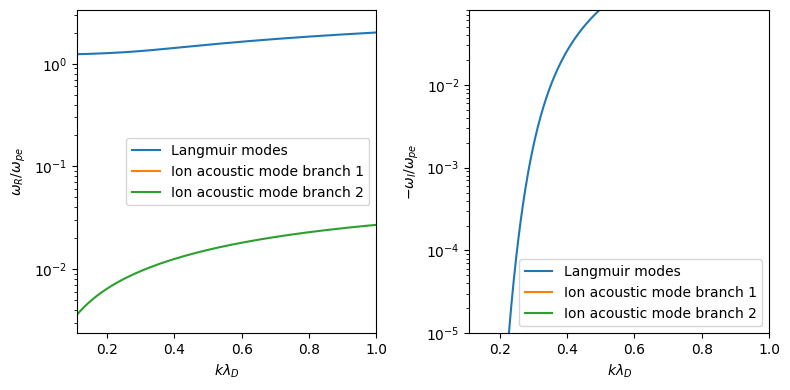

In [26]:
fig, (ax_r, ax_i) = plt.subplots(1, 2, figsize=(8,4))
ax_r.plot(kbkb, np.real(w_2ion_ub), label='Langmuir modes')
ax_r.plot(kbkb, np.real(w_2ion_lb1), label='Ion acoustic mode branch 1')
ax_r.plot(kbkb, np.real(w_2ion_lb2), label='Ion acoustic mode branch 2')
ax_r.set_xlabel(r'$k\lambda_D$')
ax_r.set_ylabel(r'$\omega_R / \omega_{pe}$')
ax_r.set_yscale('log')
ax_r.set_xlim([0.11, 1.])
ax_r.legend()
# plt.savefig('/home/mattketk/rotw/figures/two_ion_dispersion_real.png', dpi=200)

ax_i.plot(kbkb, -np.imag(w_2ion_ub), label='Langmuir modes')
ax_i.plot(kbkb, -np.imag(w_2ion_lb1), label='Ion acoustic mode branch 1')
ax_i.plot(kbkb, np.imag(w_2ion_lb2), label='Ion acoustic mode branch 2')
# ax_i.errorbar(klD, -wi, yerr=wi_stdev, fmt='o', ms=4, label='Simulation results e1')
# ax_i.errorbar(klD_n1, -wi_n1, yerr=wi_stdev_n1, fmt='o', ms=4, label='Simulation results n1')
ax_i.set_xlabel(r'$k\lambda_D$')
ax_i.set_ylabel(r'$-\omega_I / \omega_{pe}$')
ax_i.set_yscale('log')
ax_i.set_xlim([0.11, 1.])
ax_i.set_ylim([1e-5, 1.])
ax_i.set_ylim([1e-5, 8e-2])
ax_i.legend()

fig.tight_layout()
# fig.savefig('/home/mattketk/rotw/figures/theory-sim_damping-agreement.png', dpi=200)

# np.save('/home/mattketk/rotw/data/kbkb.npy', kbkb)
# np.save('/home/mattketk/rotw/data/w_2ion_ub.npy', w_2ion_ub)
# np.save('/home/mattketk/rotw/data/w_2ion_lb1.npy', w_2ion_lb1)

In [ ]:
pltee

## Shotgunning a bunch of guesses near a known root to explore other branches of the dispersion relation

In [24]:
real_width = 5e-3
imag_width = 5e-2
n_random = 1000
root = w_2ion_lb1[50]
k = kbkb[50]

rand_real = 2*real_width * np.random.random(size=n_random) + (np.real(root) - real_width)
rand_imag = 2*imag_width * np.random.random(size=n_random) + (np.imag(root) - imag_width)
guesses = rand_real + 1j * rand_imag



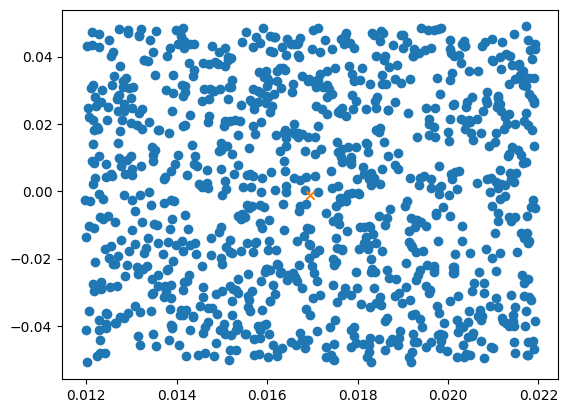

In [25]:
plt.scatter(np.real(guesses), np.imag(guesses))
plt.scatter(np.real(root), np.imag(root), marker='x')

In [26]:
root_candidates = np.zeros_like(guesses, dtype=np.complex128)
for i in range(len(guesses)):
    def helper_2ion(w):
        return two_ion_dielectric(w, k, d1, d2, e1, e2, th1, th2)

    def helper_2ion_deriv(w):
        return two_ion_dielectric_deriv(w, k, d1, d2, e1, e2, th1, th2)

    def solver(z_guess):
        return complex_newton_solve(helper_2ion, helper_2ion_deriv, z_guess)

    root_candidates[i] = solver(guesses[i])

/tmp/ipykernel_272837/2983666247.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return z_guess - f(z_guess) / fprime(z_guess)


In [27]:
# np.argwhere(counts)
counts

NameError: name 'counts' is not defined

In [46]:
bins[np.argwhere(counts == 41)]

array([[9.14822684e-09]])

In [47]:
bins[1] - bins[0]

np.float64(0.02065476950413281)

In [42]:
bins[50]

np.float64(1.6231723742876625e-08)

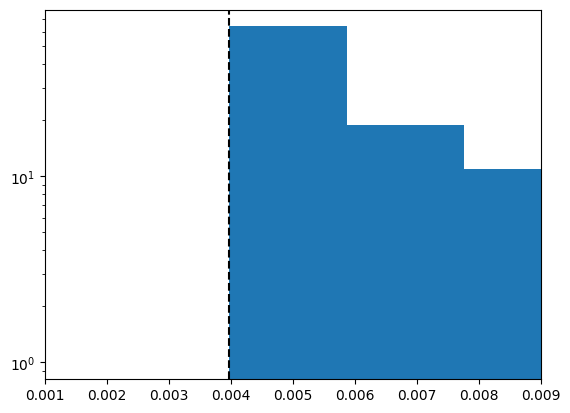

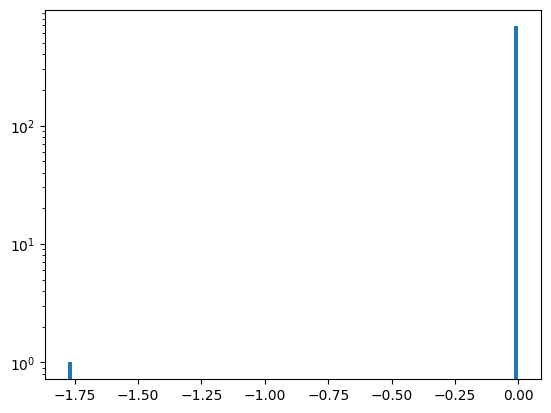

In [66]:
plt.figure()
counts, bins, _ = plt.hist(np.abs(np.real(root_candidates)), bins='auto')
plt.axvline(np.real(root), ls='--', c='k')
# plt.xscale('log')
plt.xlim([1e-3, 9e-3])
plt.yscale('log')

plt.figure()
plt.hist(np.imag(root_candidates), bins=100)
# plt.xscale('log')
plt.yscale('log')

In [29]:
np.sum(np.isnan(np.real(root_candidates)))

np.int64(162)